# Documentation

This file plots the 'Qobs' SST pattern from Neale and Hoskins (2000), used in the Aqua-planet simulations performed by Mu-Ting Chien

# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import config
import coords
from auxiliary_functions.plotting_utils import bmh_colors
from auxiliary_functions.plotting_utils import tick_labeller

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

logger.info("Loading Imports...")

# Plot data

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//
Output filename: Qobs SST Boundary Condition
Saving...                              ✔


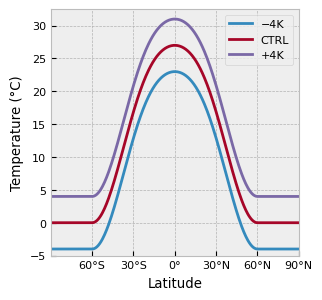

In [ ]:
phi = np.arange(-90, 90.5, 0.5)
SST = {}
SST['0K'] = np.zeros_like(phi)
SST['0K'][np.abs(phi) <= 60] = 27*(
    1
    - 0.5*(np.sin(np.pi*phi[np.abs(phi) <= 60]/120)**2)
    - 0.5*(np.sin(np.pi*phi[np.abs(phi) <= 60]/120)**4)
)
SST['-4K'] = SST['0K'] - 4
SST['4K'] = SST['0K'] + 4

savefig = True
plt.style.use('bmh')
plt.rcParams.update({'font.size':8})
[fig, ax] = plt.subplots(1, 1, figsize=(3.2, 3.2))

# ax.axhline(y=0, ls=':', color='#bcbcbc', lw=1.5)
# ax.axvline(x=0, ls=':', color='#bcbcbc', lw=1.5)

for index, experiment in enumerate(coords.experiments.values):

    ax.plot(
        phi,
        SST[experiment],
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        lw=2
    )

ax.legend(loc='best')
ax.set_xlim(-90,90)
ax.set_xticks(np.arange(-90, 90+30, 30), labels=tick_labeller(np.arange(-90, 90+30, 30), 'lat', precision=0), ha='center')
ax.set_xlabel('Latitude')
ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))
ax.set_ylim(-5, 32.5)
ax.set_yticks(np.arange(-5, 35, 5))
ax.set_ylabel("Temperature (°C)")
# ax.set_aspect(
#     np.abs((ax.get_xlim()[1] - ax.get_xlim()[0])/(ax.get_ylim()[1] - ax.get_ylim()[0]))
# )

output_filename = 'Qobs SST Boundary Condition'
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
logger.info(f"Output filename: {output_filename}")
if savefig:
    logger.info("Saving...")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.pdf",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()